In [6]:
import pandas as pd

esp_results = pd.read_csv("results_esp_proteins.csv")
esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("results_np_classifier_proteins.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

prosmith = pd.read_csv("prosmith_results_proteins.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("results_xgb_np_esm2_proteins.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("results_xgb_np_prot_bert_proteins.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("results_xgb_np_esm1b_proteins.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

similarity_method = pd.read_csv("similarity_evaluation_proteins.csv")
similarity_method["model"] = "BLASTp + Tanimoto"

In [7]:
results = pd.concat(
    [
        esp_results,
        prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b,
        similarity_method
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,identity,model
0,0.664923,0.654137,0.870799,0.523810,0.856279,0.411327,0.0,0.0,80,ESP (state of the art)
1,0.658876,0.646682,0.857916,0.518916,0.851913,0.395977,1.0,0.0,80,ESP (state of the art)
2,0.674706,0.660714,0.870426,0.532435,0.862259,0.424525,2.0,0.0,80,ESP (state of the art)
3,0.673415,0.657108,0.859970,0.531686,0.856703,0.417149,3.0,0.0,80,ESP (state of the art)
4,0.659692,0.646082,0.853622,0.519723,0.851061,0.394785,4.0,0.0,80,ESP (state of the art)
...,...,...,...,...,...,...,...,...,...,...
13,0.824362,0.778901,0.769733,0.788290,0.904672,0.633375,3.0,NaN,40,XGBoost-NPClassifierFP-ESM1b
14,0.818876,0.779306,0.795648,0.763623,0.905991,0.626209,4.0,NaN,40,XGBoost-NPClassifierFP-ESM1b
0,0.353752,0.457097,0.747109,0.329278,NaN,-0.157981,NaN,NaN,80,BLASTp + Tanimoto
1,0.340419,0.410940,0.693746,0.291933,NaN,-0.162611,NaN,NaN,60,BLASTp + Tanimoto


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Remove NaN identities
df = results.dropna(subset=["identity"]).copy()

# Aggregate mean and std per model + identity
agg = (
    df
    .groupby(["identity", "model"])
    .agg(
        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
)

identity_order = sorted(agg["identity"].unique())
models = [
    'BLASTp + Tanimoto',
    'ESP (state of the art)',
    'ProSmith (state of the art)',
    'XGBoost-NPClassifierFP-ESM2',
    'XGBoost-NPClassifierFP-ProtBERT',
    'XGBoost-NPClassifierFP-ESM1b'
]

# Define colorblind-friendly colors for each model
fixed_colors = {
    'BLASTp + Tanimoto': "#bcbd22",  # Gold
    'ESP (state of the art)': "#1f77b4",  # Blue
    'ProSmith (state of the art)': "#2ca02c",  # Green
    'XGBoost-NPClassifierFP-ESM2': "#ff7f0e",  # Orange
    'XGBoost-NPClassifierFP-ProtBERT': "#9467bd",  # Purple
    'XGBoost-NPClassifierFP-ESM1b': "#8c564b"  # Brown
}

# Define patterns for each model
patterns = {
    'BLASTp + Tanimoto': "//",  # Diagonal lines
    'ESP (state of the art)': "o",  # Circles
    'ProSmith (state of the art)': "\\",  # Backslash lines
    'XGBoost-NPClassifierFP-ESM2': "x",
      # Crosses
    'XGBoost-NPClassifierFP-ProtBERT': "+",
      # Plus signs
    'XGBoost-NPClassifierFP-ESM1b': "s",
      # Squares
}

# Map models to colors and patterns
palette = {model: fixed_colors[model] for model in models}
hatches = {model: patterns[model] for model in models}

metrics = {
    "mcc": ("mcc_mean", "mcc_std"),
    "f1_score": ("f1_mean", "f1_std")
}

for metric, (mean_col, std_col) in metrics.items():

    fig, ax = plt.subplots(figsize=(14, 6))

    group_width = 0.8
    x_positions = np.arange(len(identity_order))

    for i, identity in enumerate(identity_order):

        subset = agg[agg["identity"] == identity]

        # Sort within identity by mean performance
        subset_sorted = subset.sort_values(mean_col, ascending=False)

        n_models = len(subset_sorted)
        bar_width = group_width / n_models

        for j, (_, row) in enumerate(subset_sorted.iterrows()):

            xpos = x_positions[i] - group_width/2 + j*bar_width + bar_width/2

            ax.bar(
                xpos,
                row[mean_col],
                width=bar_width,
                color=palette[row["model"]],
                edgecolor="black",  # Add black edges
                hatch=hatches[row["model"]],  # Add pattern
                yerr=row[std_col],
                capsize=3,
                error_kw=dict(linewidth=1)
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([int(i) for i in identity_order])
    ax.set_xlabel("Identity Threshold", fontsize=17)
    ax.set_ylabel(metric.upper(), fontsize=17)
    # ax.set_title(f"{metric.upper()} – Models Ranked Within Each Protein Identity", fontsize=14)
    if metric == "mcc":
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)

    # Save the plot without the legend
    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_proteins_no_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    # Create a separate figure for the legend with both colors and patterns
    legend_handles = [
        Patch(
            facecolor=palette[m],
            label=m,
            edgecolor="black",
            hatch=hatches[m]
        ) for m in models
    ]
    fig_legend = plt.figure(figsize=(6, 2))
    fig_legend.legend(handles=legend_handles, loc="center", title="Method", ncol=1)
    fig_legend.savefig(f"{metric}_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    plt.close(fig_legend)
    plt.close(fig)


/tmp/ipykernel_485324/2814862528.py:86: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.bar(
/tmp/ipykernel_485324/2814862528.py:114: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  Patch(
/tmp/ipykernel_485324/2814862528.py:86: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.bar(
/tmp/ipykernel_485324/2814862528.py:114: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since

In [9]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier_compounds.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

esp_results = pd.read_csv("results_esp_compounds.csv")
esp_results["model"] = "ESP (state of the art)"

prosmith = pd.read_csv("prosmith_results_compounds.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("results_xgb_np_esm2_compounds.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"


xgb_results_prot_bert = pd.read_csv("results_xgb_np_prot_bert_compounds.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("results_xgb_np_esm1b_compounds.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

similarity_method = pd.read_csv("similarity_evaluation_compounds.csv")
similarity_method["model"] = "BLASTp + Tanimoto"

results = pd.concat(
    [
        esp_results,
        # np_esm2_results,
        prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b,
        similarity_method
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,similarity,model
0,0.354455,0.358747,0.966561,0.220247,0.802876,0.182958,0.0,0.0,20,ESP (state of the art)
1,0.359661,0.360612,0.966561,0.221654,0.804926,0.187368,1.0,0.0,20,ESP (state of the art)
2,0.361148,0.360578,0.964172,0.221754,0.815399,0.186438,2.0,0.0,20,ESP (state of the art)
3,0.364421,0.361572,0.963376,0.222549,0.812632,0.188478,3.0,0.0,20,ESP (state of the art)
4,0.351926,0.358037,0.967357,0.219671,0.802797,0.181546,4.0,0.0,20,ESP (state of the art)
...,...,...,...,...,...,...,...,...,...,...
19,0.876097,0.713844,0.827229,0.627795,0.929647,0.646527,4.0,NaN,20,XGBoost-NPClassifierFP-ESM1b
0,0.611632,0.263885,0.372611,0.204278,NaN,0.032200,NaN,NaN,20,BLASTp + Tanimoto
1,0.602294,0.087719,0.140845,0.063694,NaN,-0.137788,NaN,NaN,40,BLASTp + Tanimoto
2,0.280155,0.236699,0.290845,0.199549,NaN,-0.426732,NaN,NaN,60,BLASTp + Tanimoto


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Remove NaN identities
df = results.dropna(subset=["similarity"]).copy()

# Aggregate mean and std per model + identity
agg = (
    df
    .groupby(["similarity", "model"])
    .agg(
        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
)

identity_order = sorted(agg["similarity"].unique())
models = sorted(agg["model"].unique())

# Define colorblind-friendly colors for each model
fixed_colors = {
    'BLASTp + Tanimoto': "#bcbd22",  # Gold
    'ESP (state of the art)': "#1f77b4",  # Blue
    'ProSmith (state of the art)': "#2ca02c",  # Green
    'XGBoost-NPClassifierFP-ESM2': "#ff7f0e",  # Orange
    'XGBoost-NPClassifierFP-ProtBERT': "#9467bd",  # Purple
    'XGBoost-NPClassifierFP-ESM1b': "#8c564b"  # Brown
}

# Define patterns for each model
patterns = {
    'BLASTp + Tanimoto': "//",  # Diagonal lines
    'ESP (state of the art)': "o",  # Circles
    'ProSmith (state of the art)': "\\",  # Backslash lines
    'XGBoost-NPClassifierFP-ESM2': "x",
      # Crosses
    'XGBoost-NPClassifierFP-ProtBERT': "+",
      # Plus signs
    'XGBoost-NPClassifierFP-ESM1b': "s",
      # Squares
}

# Map models to colors and patterns
palette = {model: fixed_colors.get(model, "#d62728") for model in models}
hatches = {model: patterns.get(model, "") for model in models}

metrics = {
    "mcc": ("mcc_mean", "mcc_std"),
    "f1_score": ("f1_mean", "f1_std")
}

for metric, (mean_col, std_col) in metrics.items():

    fig, ax = plt.subplots(figsize=(14, 6))

    group_width = 0.8
    x_positions = np.arange(len(identity_order))

    for i, identity in enumerate(identity_order):

        subset = agg[agg["similarity"] == identity]

        # Sort within identity by mean performance
        subset_sorted = subset.sort_values(mean_col, ascending=False)

        n_models = len(subset_sorted)
        bar_width = group_width / n_models

        for j, (_, row) in enumerate(subset_sorted.iterrows()):

            xpos = x_positions[i] - group_width/2 + j*bar_width + bar_width/2

            ax.bar(
                xpos,
                row[mean_col],
                width=bar_width,
                color=palette[row["model"]],
                edgecolor="black",  # Add black edges
                hatch=hatches[row["model"]],  # Add pattern
                yerr=row[std_col],
                capsize=3,
                error_kw=dict(linewidth=1)
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([int(i) for i in identity_order])
    ax.set_xlabel("Similarity Threshold", fontsize=17)
    ax.set_ylabel(metric.upper(), fontsize=17)
    # ax.set_title(f"{metric.upper()} – Models Ranked Within Each Compound Similarity", fontsize=14)
    if metric == "mcc":
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)

    # Save the plot without the legend
    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_compounds_no_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    # Create a separate figure for the legend with both colors and patterns
    legend_handles = [
        Patch(
            facecolor=palette[m],
            label=m,
            edgecolor="black",
            hatch=hatches[m]
        ) for m in models
    ]
    fig_legend = plt.figure(figsize=(6, 2))
    fig_legend.legend(handles=legend_handles, loc="center", title="Method", ncol=1)
    fig_legend.savefig(f"{metric}_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    plt.close(fig_legend)
    plt.close(fig)


/tmp/ipykernel_485324/1535219622.py:79: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.bar(
/tmp/ipykernel_485324/1535219622.py:107: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  Patch(
/tmp/ipykernel_485324/1535219622.py:79: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.bar(


/tmp/ipykernel_485324/1535219622.py:107: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "s". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  Patch(


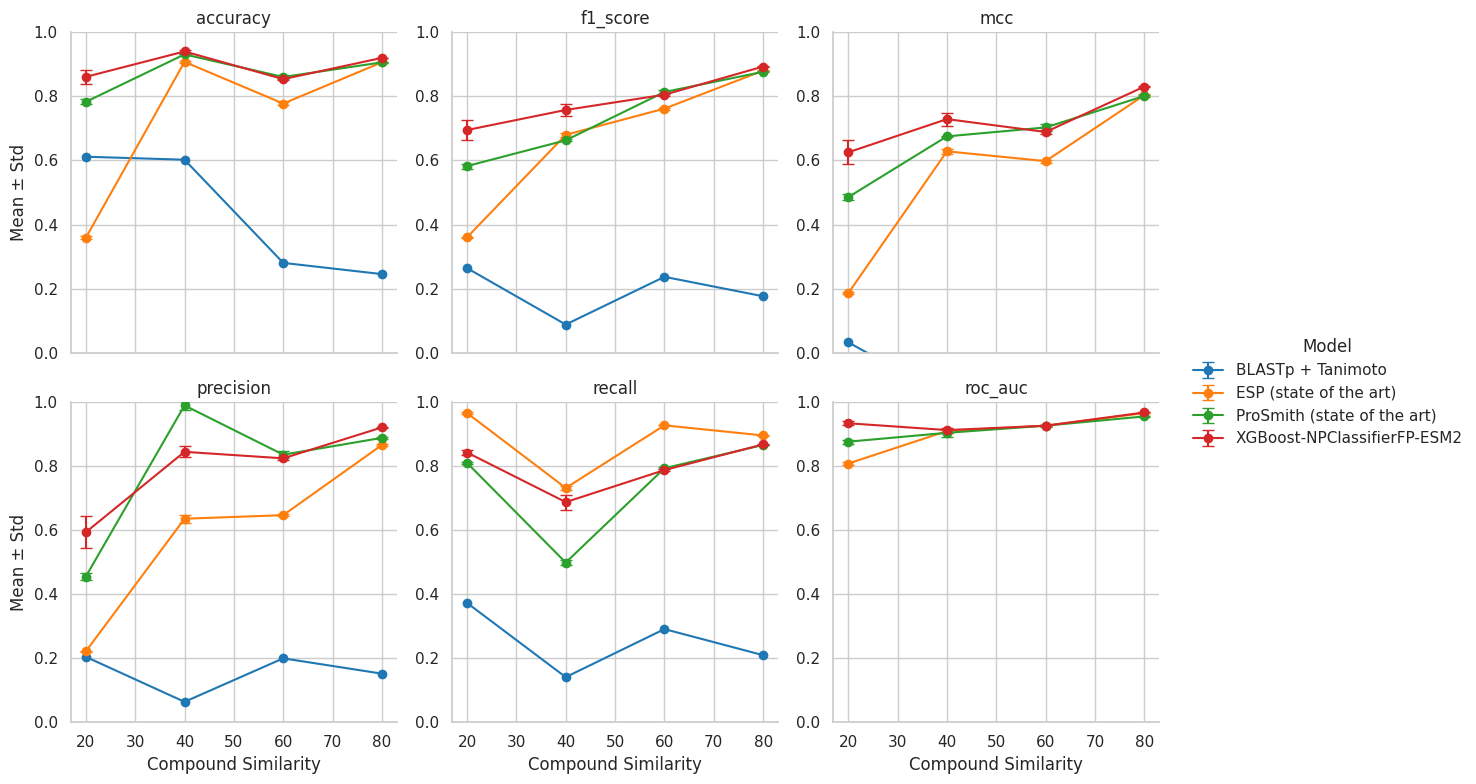

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'similarity'],
                    value_vars=['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc'],
                    var_name='metric', value_name='value')
                    

# Compute mean and std
summary_df = df_melted.groupby(['model', 'similarity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('similarity')
    plt.errorbar(data['similarity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Compound Similarity", "Mean ± Std")
g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results.png", dpi=300, transparent=True)
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results[results["similarity"]==60]['f1_score'],  # Dependent variable
    groups=results[results["similarity"]==60]['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------
    ESP  NP-ESM2   0.0465    0.0 0.0361 0.0569   True
    ESP ProSmith   0.0518    0.0 0.0415 0.0622   True
NP-ESM2 ProSmith   0.0053 0.3836 -0.005 0.0157  False
-----------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results[results["identity"]==60]['mcc'],  # Dependent variable
    groups=results[results["identity"]==60]['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------
    ESP  NP-ESM2   0.2765    0.0 0.1966 0.3564   True
    ESP ProSmith   0.3174    0.0 0.2375 0.3974   True
NP-ESM2 ProSmith   0.0409 0.3885 -0.039 0.1209  False
-----------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['recall'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower   upper  reject
-------------------------------------------------------
    ESP  NP-ESM2  -0.2104    0.0 -0.2602 -0.1607   True
    ESP ProSmith  -0.1825    0.0 -0.2323 -0.1328   True
NP-ESM2 ProSmith   0.0279 0.3697 -0.0219  0.0777  False
-------------------------------------------------------


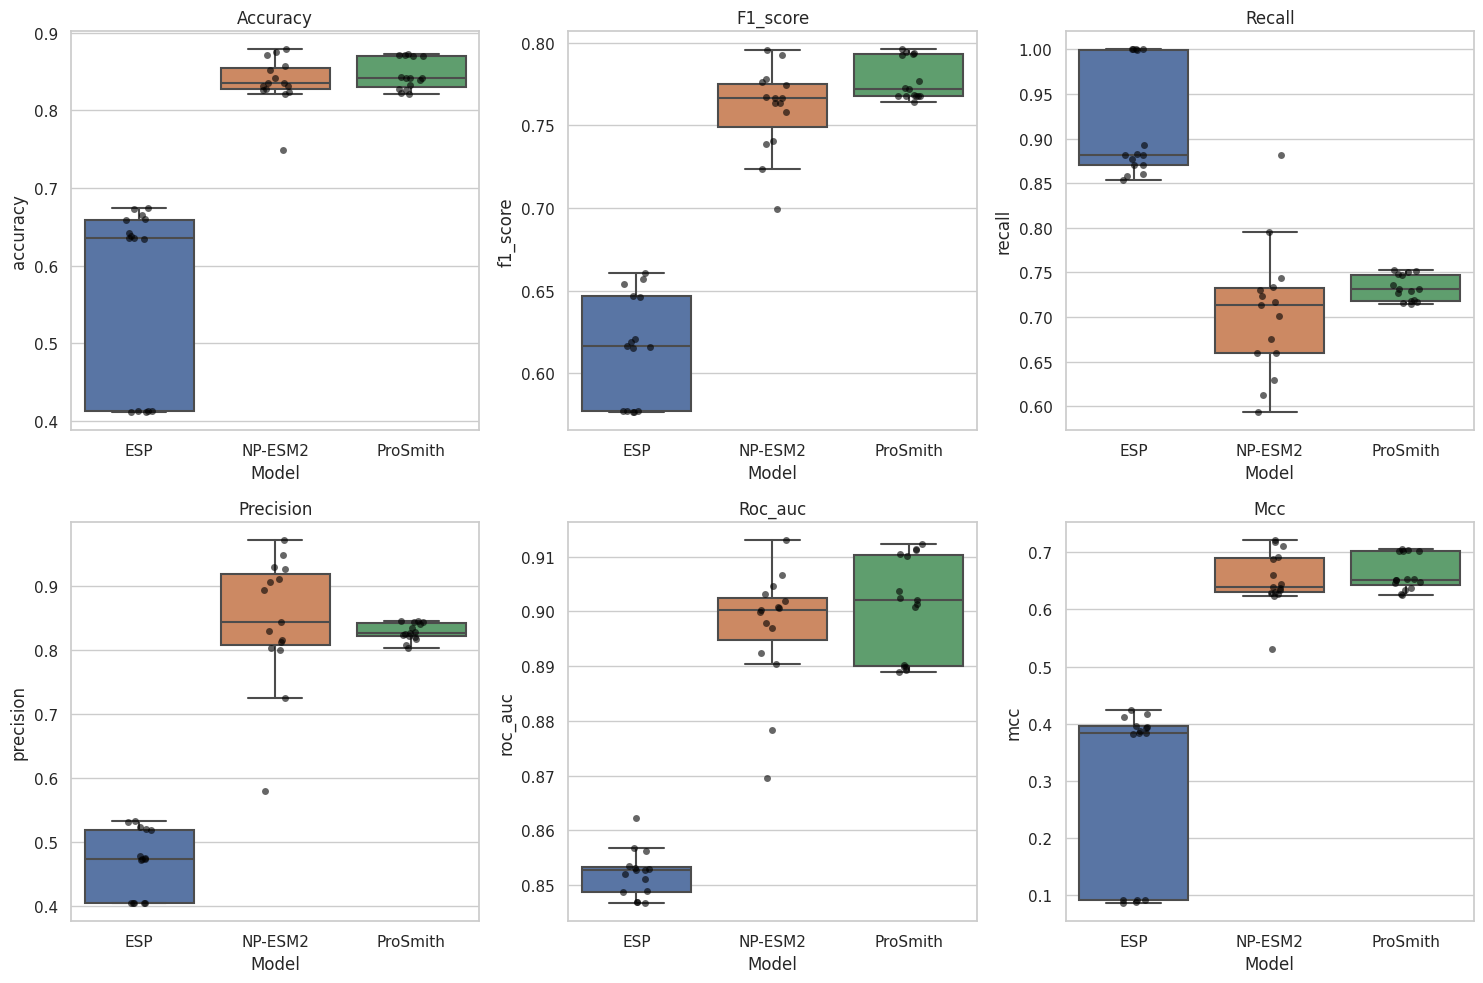

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier.csv")
np_esm2_results["model"] = "NP-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_gat_results = pd.read_csv("results_gat_np_classifier.csv")
np_esm2_gat_results["model"] = "NP-ESM2-GAT"
np_esm2_gat_results = np_esm2_gat_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_focal_bce_results = pd.read_csv("results_np_classifier_focal_bce.csv")
np_esm2_focal_bce_results["model"] = "NP-ESM2-FocalBCE"
np_esm2_focal_bce_results = np_esm2_focal_bce_results.rename(columns={"f1_macro": "f1_score"})

np_esm2_bce_results = pd.read_csv("results_np_classifier_bce.csv")
np_esm2_bce_results["model"] = "NP-ESM2-BCE"
np_esm2_bce_results = np_esm2_bce_results.rename(columns={"f1_macro": "f1_score"})


In [ ]:
results = pd.concat(
    [
        np_esm2_results,
        np_esm2_gat_results,
        np_esm2_focal_bce_results,
        np_esm2_bce_results
        
    ]
)


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['f1_score'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
         NP-ESM2      NP-ESM2-BCE   0.0213 0.7018 -0.0348 0.0775  False
         NP-ESM2 NP-ESM2-FocalBCE  -0.0065 0.9872 -0.0626 0.0497  False
         NP-ESM2      NP-ESM2-GAT   0.0209  0.716 -0.0353  0.077  False
     NP-ESM2-BCE NP-ESM2-FocalBCE  -0.0278 0.5072 -0.0839 0.0283  False
     NP-ESM2-BCE      NP-ESM2-GAT  -0.0005    1.0 -0.0566 0.0557  False
NP-ESM2-FocalBCE      NP-ESM2-GAT   0.0273 0.5215 -0.0288 0.0835  False
-----------------------------------------------------------------------


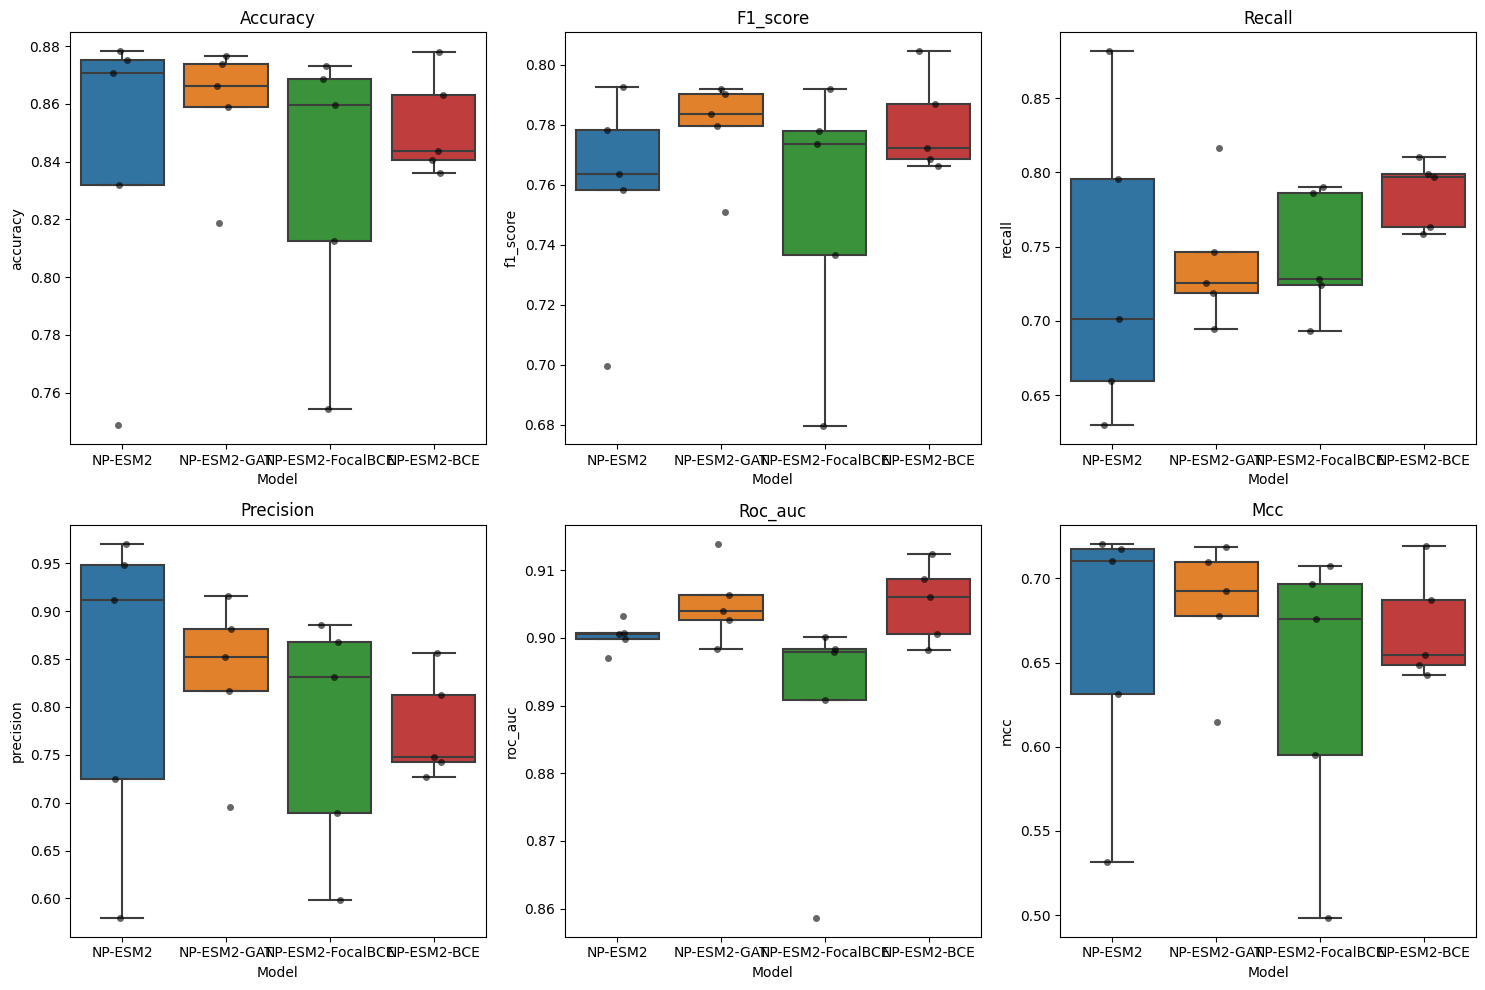

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()